# asf_sample.py — Step-by-step exploration

Follows the execution of `scripts/asf_sample.py main()` cell-by-cell, visualising intermediate results at each stage.

**Input data:** `genome-blender_run/single_short_shallow` (shallow short-read PE data)

> **Prerequisite:** `run_asf_sample.sh` must have been run first to produce the rust-mdbg LMDB indexes
> (`{prefix}.index.lmdb`, `{prefix}.kminmer_index.lmdb`, `{prefix}.kminmer_bloom.bin`,
> `{prefix}.pe_combo.lmdb`).

## 0  Setup
### Paths and imports

In [2]:
from __future__ import annotations

import json
import logging
import math
import mmap
import random
import struct
from collections import Counter, OrderedDict, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import IO

import lmdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, Predictive, SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDelta, AutoNormal
from pyro.optim import ClippedAdam
from rich.progress import BarColumn, MofNCompleteColumn, Progress, SpinnerColumn, TimeElapsedColumn
import torch
import torch.nn.functional as F

from rich.progress import BarColumn, MofNCompleteColumn, Progress, SpinnerColumn, TextColumn

In [3]:
# ── paths (mirror run_asf_sample.sh) ─────────────────────────────────────────
FP = Path("../../genome-blender_run/multi_genome_full/output/rust-mdbg").resolve()
PREFIX = FP / "rust_mdbg_out"

# rust-mdbg parameters (must match what run_asf_sample.sh used)
K = 7             # minimizer k-mer order (--k)
L = 17            # l-mer length
MINABUND = 2
COMBO_DENSITY = 0.99
COMBO_MAX_DISTANCE = 1

# asf_sample parameters
N_PATHS = 200
MAX_PATH_MERS = 5000
MIN_SUPPORT = 1
MAX_READS_PER_KMER = 200
SEED = 42

# Insert size estimation
INSERT_SIZE_BINS = [float(x) for x in
    "0,200,400,600,800,1000,1500,2000,3000,4000,6000,8000,12000,16000,20000".split(",")]
INSERT_SIZE_INFERENCE = "nuts"
INSERT_SIZE_PATHS = 50
MIN_PATH_HASHES_PER_BIN = 50

# Read length estimation
READ_LENGTH_READS = 1000

print(f"Reads LMDB    : {Path(f'{PREFIX}.index.lmdb').exists()}")
print(f"Kminmer LMDB  : {Path(f'{PREFIX}.kminmer_index.lmdb').exists()}")
print(f"Bloom filter  : {Path(f'{PREFIX}.kminmer_bloom.bin').exists()}")
print(f"PE combo LMDB : {Path(f'{PREFIX}.pe_combo.lmdb').exists()}")

Reads LMDB    : False
Kminmer LMDB  : False
Bloom filter  : False
PE combo LMDB : False


## 1  Functions

All functions from `scripts/asf_sample.py` are reproduced here for inspection.

### Data structures and constants

In [4]:
_LMDB_MAP_SIZE = 128 * 1024 * 1024 * 1024  # 128 GB
_LMDB_MAX_DBS = 8

# Combo hash mixing constants — must match rust-mdbg's canonical_combo_hash.
_UINT64_MAX: int = (1 << 64) - 1
_COMBO_CM1 = np.uint64(0x9E3779B97F4A7C15)
_COMBO_CM2 = np.uint64(0x6C62272E07BB0142)  # Rust value — differs from notebook CM2
_COMBO_CM3 = np.uint64(0x94D049BB133111EB)

_PROGRESS_COLUMNS = (
    SpinnerColumn(),
    TextColumn("[progress.description]{task.description}"),
    BarColumn(),
    MofNCompleteColumn(),
    TextColumn("[cyan]{task.elapsed:.1f}s"),
)

@dataclass
class PathResult:
    """A sampled path through the minimizer-space de Bruijn graph."""

    minimizer_ids: list[int]
    distances: list[int]
    support: list[int]


@dataclass
class FragmentLengthEstimate:
    """Posterior estimate of the log-normal fragment length distribution."""

    mu_log: float
    sigma_log: float
    mu_log_ci: tuple[float, float]
    sigma_log_ci: tuple[float, float]
    rho: float
    norm: float
    median: float
    mean: float
    n_bins_used: int
    inference: str
    signal_reliable: bool = True


@dataclass
class FragmentLengthMAP:
    """MAP point estimate of the log-normal fragment length distribution."""

    mu_log: float
    sigma_log: float
    rho: float
    norm: float
    median: float
    mean: float
    n_bins_used: int
    signal_reliable: bool = True
    loss_final: float = float("nan")


@dataclass
class ReadLengthMAP:
    """MAP point estimate of the log-normal read length distribution."""

    mu_log: float
    sigma_log: float
    median: float
    mean: float
    n_reads: int
    signal_reliable: bool = True
    loss_final: float = float("nan")


@dataclass
class _BloomFilter:
    """Bloom filter backed by an mmap view of the on-disk bit array."""

    bits: np.ndarray
    n_bits: int
    n_hash_fns: int
    k: int
    l: int  # noqa: E741
    _mm: mmap.mmap = field(default=None, repr=False)   # type: ignore[assignment]
    _file: IO[bytes] = field(default=None, repr=False)  # type: ignore[assignment]


class _LRUCache:
    """Bounded LRU cache backed by OrderedDict."""

    def __init__(self, maxsize: int) -> None:
        self._data: OrderedDict = OrderedDict()
        self.maxsize = maxsize
        self.hits = 0
        self.misses = 0

    def get(self, key):
        try:
            self._data.move_to_end(key)
            self.hits += 1
            return self._data[key]
        except KeyError:
            self.misses += 1
            return None

    def put(self, key, value) -> None:
        if key in self._data:
            self._data.move_to_end(key)
        self._data[key] = value
        if len(self._data) > self.maxsize:
            self._data.popitem(last=False)

    @property
    def hit_rate(self) -> float:
        total = self.hits + self.misses
        return self.hits / total if total else 0.0

    def __len__(self) -> int:
        return len(self._data)


### Bloom filter

In [5]:
def _open_bloom(path: Path) -> _BloomFilter:
    """Open a bloom filter (minimizer or kminmer) with mmap-backed disk access."""
    with open(path, "rb") as f:
        header = f.read(48)
    magic = header[:8]
    if magic == b"MNBLOOMB":
        # 40-byte header: magic(8) + version(8) + l(8) + n_bits(8) + n_hash_fns(8) — no k field.
        _, l, n_bits, n_hash_fns = struct.unpack_from("<QQQQ", header, offset=8)
        k = 0
        data_offset = 40
    elif magic == b"KMBLOOMB":
        # 48-byte header: magic(8) + version(8) + k(8) + l(8) + n_bits(8) + n_hash_fns(8).
        _, k, l, n_bits, n_hash_fns = struct.unpack_from("<QQQQQ", header, offset=8)
        data_offset = 48
    else:
        raise ValueError(f"Unknown bloom filter magic: {magic!r}")
    file_obj: IO[bytes] = open(path, "rb")
    mm = mmap.mmap(file_obj.fileno(), 0, access=mmap.ACCESS_READ)
    bits = np.frombuffer(mm, dtype=np.uint64, offset=data_offset)
    return _BloomFilter(bits=bits, n_bits=n_bits, n_hash_fns=n_hash_fns,
                        k=k, l=l, _mm=mm, _file=file_obj)


def _fnv1a64(data: bytes) -> int:
    """Return the FNV-1a 64-bit hash of data, matching the Rust implementation."""
    h = 14695981039346656037
    for b in data:
        h = ((h ^ b) * 1099511628211) & 0xFFFFFFFFFFFFFFFF
    return h


def _bloom_check(bloom: _BloomFilter, kmer_bytes: bytes) -> bool:
    """Return True if kmer_bytes is possibly present in the bloom filter."""
    h1 = _fnv1a64(kmer_bytes)
    h2 = (((h1 << 17) | (h1 >> 47)) * 0x9E3779B97F4A7C15) & 0xFFFFFFFFFFFFFFFF
    for i in range(3):
        pos = ((h1 + i * h2) & 0xFFFFFFFFFFFFFFFF) % bloom.n_bits
        if not (int(bloom.bits[pos >> 6]) & (1 << (pos & 63))):
            return False
    return True


def _minimizer_bloom_check(bloom: _BloomFilter, minimizer_hash: int) -> bool:
    """Return True if a single minimizer hash is possibly present in the bloom."""
    return _bloom_check(bloom, struct.pack("<Q", minimizer_hash))

### LMDB helpers

In [6]:
def _load_shard_paths(prefix: Path, shard_list_suffix: str, single_suffix: str) -> list[Path]:
    """Return shard paths from a shard-list file, or a single-path list if no sharding."""
    shard_list = Path(f"{prefix}{shard_list_suffix}")
    if shard_list.exists():
        return [Path(p) for p in shard_list.read_text().splitlines() if p.strip()]
    return [Path(f"{prefix}{single_suffix}")]


def _reads_shard_ranges(shards: list[tuple]) -> list[tuple[int | None, int | None]]:
    """Return the inclusive (lo, hi) read-ID range stored in each reads shard."""
    ranges: list[tuple[int | None, int | None]] = []
    for env, db, _ in shards:
        with env.begin() as txn:
            cursor = txn.cursor(db=db)
            if not cursor.first():
                ranges.append((None, None))
                continue
            lo_raw = cursor.key()
            cursor.last()
            hi_raw = cursor.key()
        lo = struct.unpack("<Q", lo_raw)[0] if len(lo_raw) == 8 else None
        hi = struct.unpack("<Q", hi_raw)[0] if len(hi_raw) == 8 else None
        ranges.append((lo, hi))
    return ranges


def _open_reads_lmdb(prefix: Path) -> tuple[list[tuple], bool]:
    """Open reads LMDB(s) produced by rust-mdbg --dump-read-minimizers.

    Detects sharding automatically via ``{prefix}.index_shard_list``.

    Returns:
        Tuple of (shards, has_positions) where shards is a list of
        (env, reads_db, meta_db_or_None) tuples — one per shard.
    """
    paths = _load_shard_paths(prefix, ".index_shard_list", ".index.lmdb")
    shards: list[tuple] = []
    has_positions = False
    for path in paths:
        env = lmdb.open(
            str(path), readonly=True, lock=False,
            max_dbs=_LMDB_MAX_DBS, map_size=_LMDB_MAP_SIZE,
        )
        db = env.open_db(b"reads")
        try:
            meta_db = env.open_db(b"meta")
            with env.begin() as txn:
                flag = txn.get(b"has_positions", db=meta_db)
            if flag == b"\x01":
                has_positions = True
        except lmdb.ReadonlyError:
            meta_db = None
        shards.append((env, db, meta_db))
    return shards, has_positions


def _open_minimizer_lmdb(prefix: Path) -> list[tuple]:
    """Open minimizer index LMDB(s) produced by rust-mdbg --dump-minimizer-index.

    Sub-database ``minimizers`` uses DUPSORT layout:
      key   = minimizer hash (u64 LE, 8 bytes)
      value = 1-based read index (u64 LE, 8 bytes)

    Detects sharding automatically via ``{prefix}.minimizer_index_shard_list``.

    Returns:
        List of (env, minimizers_db, meta_db_or_None) tuples — one per shard.
    """
    paths = _load_shard_paths(
        prefix, ".minimizer_index_shard_list", ".minimizer_index.lmdb",
    )
    shards: list[tuple] = []
    for path in paths:
        env = lmdb.open(
            str(path), readonly=True, lock=False,
            max_dbs=_LMDB_MAX_DBS, map_size=_LMDB_MAP_SIZE,
        )
        db = env.open_db(b"minimizers", dupsort=True, dupfixed=True)
        try:
            meta_db = env.open_db(b"meta")
        except lmdb.ReadonlyError:
            meta_db = None
        shards.append((env, db, meta_db))
    return shards


def _decode_read(val: bytes, has_positions: bool) -> tuple[np.ndarray, np.ndarray]:
    """Decode a reads LMDB value into (minimizer_ids uint64, positions int64)."""
    if has_positions:
        n = len(val) // 12
        if n == 0:
            return np.empty(0, np.uint64), np.empty(0, np.int64)
        raw = np.frombuffer(val, dtype=np.uint8).reshape(n, 12)
        mids = np.frombuffer(raw[:, :8].tobytes(), dtype="<u8").copy()
        pos = np.frombuffer(raw[:, 8:12].tobytes(), dtype="<u4").astype(np.int64)
    else:
        n = len(val) // 8
        mids = (
            np.frombuffer(val[: n * 8], dtype="<u8").copy()
            if n else np.empty(0, np.uint64)
        )
        pos = np.zeros(len(mids), np.int64)
    return mids, pos


def _read_key(read_id: int) -> bytes:
    """Encode a read ID as an LMDB key (8-byte LE, matching rust-mdbg)."""
    return struct.pack("<Q", read_id)


def _n_reads_from_shards(reads_txns_dbs_metas: list[tuple]) -> int | None:
    """Return the global read count from the first shard that has meta."""
    for txn, _db, meta_db in reads_txns_dbs_metas:
        if meta_db is None:
            continue
        val = txn.get(b"n_reads", db=meta_db)
        if val is not None:
            return struct.unpack_from("<Q", val)[0]
    return None


def _sample_read_ids(
    reads_txns_dbs_metas: list[tuple],
    n: int,
    rng: random.Random,
) -> list[int]:
    """Return a list of up to n random 1-based read IDs.

    Prefers the fast path (sample from 1..n_reads via metadata) when available;
    falls back to scanning all LMDB keys across all shards.
    """
    total = _n_reads_from_shards(reads_txns_dbs_metas)
    if total is not None and total > 0:
        return [rng.randint(1, total) for _ in range(min(n, total))]
    # Fallback: scan all keys across all shards.
    keys: list[int] = []
    for txn, db, _meta in reads_txns_dbs_metas:
        cursor = txn.cursor(db=db)
        for key, _ in cursor.iternext():
            if len(key) == 8:
                keys.append(struct.unpack("<Q", key)[0])
            else:
                try:
                    keys.append(int(key))
                except (ValueError, UnicodeDecodeError):
                    continue
    return rng.sample(keys, min(n, len(keys)))


def _read_ids_for_minimizer_multi(
    mi_txns_dbs: list[tuple],
    minimizer_hash: int,
    limit: int,
) -> list[int]:
    """Return up to *limit* 1-based read IDs containing *minimizer_hash*.

    Queries all minimizer index shards and concatenates results.
    """
    key = struct.pack("<Q", minimizer_hash)
    ids: list[int] = []
    for txn, db in mi_txns_dbs:
        cursor = txn.cursor(db=db)
        if not cursor.set_key(key):
            continue
        for val in cursor.iternext_dup(keys=False):
            ids.append(struct.unpack_from("<Q", val)[0])
            if len(ids) >= limit:
                return ids
    return ids


def _get_read_multi(
    reads_txns_dbs: list[tuple],
    shard_ranges: list[tuple],
    read_id: int,
) -> bytes | None:
    """Fetch a raw read value across sharded reads LMDB transactions.

    Routes by precomputed shard ranges; falls back to string key for legacy.
    """
    key = _read_key(read_id)
    for (lo, hi), (txn, db) in zip(shard_ranges, reads_txns_dbs):
        if lo is not None and not (lo <= read_id <= hi):
            continue
        val = txn.get(key, db=db)
        if val is not None:
            return val
        if lo is not None:
            break
        # String-key fallback for legacy non-sharded indexes.
        val = txn.get(str(read_id).encode(), db=db)
        if val is not None:
            return val
    return None


def _get_read_cached(
    reads_txns_dbs: list[tuple],
    shard_ranges: list[tuple],
    has_positions: bool,
    read_id: int,
    cache: _LRUCache,
) -> tuple[np.ndarray, np.ndarray] | None:
    """Fetch and decode a read across sharded reads LMDB transactions."""
    cached = cache.get(read_id)
    if cached is not None:
        return cached
    val = _get_read_multi(reads_txns_dbs, shard_ranges, read_id)
    if val is None:
        return None
    result = _decode_read(val, has_positions)
    cache.put(read_id, result)
    return result


def _get_minimizer_reads_cached(
    mi_txns_dbs: list[tuple],
    minimizer_hash: int,
    limit: int,
    cache: _LRUCache,
) -> list[int]:
    """Look up reads containing *minimizer_hash* across all minimizer shards."""
    cached = cache.get(minimizer_hash)
    if cached is not None:
        return cached
    result = _read_ids_for_minimizer_multi(mi_txns_dbs, minimizer_hash, limit)
    cache.put(minimizer_hash, result)
    return result


### Path sampling

In [7]:
def _sample_path(
    seed_read_id: int,
    reads_txns_dbs: list[tuple],
    shard_ranges: list[tuple],
    has_positions: bool,
    mi_txns_dbs: list[tuple],
    bloom,
    k: int,
    max_path_mers: int,
    min_support: int,
    max_reads_per_kmer: int,
    rng: random.Random,
    read_cache,
    minimizer_cache,
    intersection_cache,
    n_filter_mers=None,
):
    """Sample one path seeded from a random k-mer window in a given read."""
    decoded = _get_read_cached(reads_txns_dbs, shard_ranges, has_positions, seed_read_id, read_cache)
    if decoded is None:
        return None
    mids, pos = decoded
    if len(mids) < k:
        return None
    start = rng.randrange(len(mids) - k + 1)
    path = list(map(int, mids[start : start + k]))
    distances = [
        int(abs(int(pos[i + 1]) - int(pos[i])))
        for i in range(start, start + k - 1)
    ]
    support = [1] * (k - 1)
    for direction in (+1, -1):
        _extend_path(
            path, distances, support, direction=direction,
            reads_txns_dbs=reads_txns_dbs, shard_ranges=shard_ranges,
            has_positions=has_positions,
            mi_txns_dbs=mi_txns_dbs, bloom=bloom,
            k=k, max_path_mers=max_path_mers,
            min_support=min_support, max_reads_per_kmer=max_reads_per_kmer,
            read_cache=read_cache, minimizer_cache=minimizer_cache,
            intersection_cache=intersection_cache,
            n_filter_mers=n_filter_mers,
        )
    return PathResult(minimizer_ids=path, distances=distances, support=support)


#### Extension logic

In [8]:
def _find_extensions(
    tip,
    tip_rev,
    reads_txns_dbs: list[tuple],
    shard_ranges: list[tuple],
    has_positions: bool,
    mi_txns_dbs: list[tuple],
    k,
    successor,
    max_reads,
    read_cache,
    minimizer_cache,
    intersection_cache,
    bloom,
    n_filter_mers=None,
):
    """Find candidate extensions via multi-minimizer intersection + full overlap check."""
    n_mers = (k - 1) if n_filter_mers is None else max(1, min(n_filter_mers, k - 1))

    if successor:
        filter_mers = [int(m) for m in tip[k - n_mers:]]
    else:
        filter_mers = [int(m) for m in tip[:n_mers]]

    if bloom is not None:
        filter_mers = [m for m in filter_mers if _minimizer_bloom_check(bloom, m)]
    if not filter_mers:
        return Counter(), {}

    read_ids = None
    build_from = len(filter_mers) - 2

    for i in range(len(filter_mers)):
        suffix_key = tuple(filter_mers[i:])
        cached = intersection_cache.get(suffix_key)
        if cached is not None:
            read_ids = set(cached)
            build_from = i - 1
            break

    if read_ids is None:
        first_ids = _get_minimizer_reads_cached(
            mi_txns_dbs, filter_mers[-1], max_reads, minimizer_cache
        )
        if not first_ids:
            return Counter(), {}
        read_ids = set(first_ids)
        intersection_cache.put((filter_mers[-1],), frozenset(read_ids))
        build_from = len(filter_mers) - 2

    for i in range(build_from, -1, -1):
        m_ids = _get_minimizer_reads_cached(
            mi_txns_dbs, filter_mers[i], max_reads, minimizer_cache
        )
        if not m_ids:
            return Counter(), {}
        read_ids &= set(m_ids)
        if not read_ids:
            return Counter(), {}
        intersection_cache.put(tuple(filter_mers[i:]), frozenset(read_ids))

    counts: Counter = Counter()
    dists: dict[int, list[int]] = defaultdict(list)

    for read_id in read_ids:
        decoded = _get_read_cached(reads_txns_dbs, shard_ranges, has_positions, read_id, read_cache)
        if decoded is None:
            continue
        mids, pos = decoded
        n = len(mids)
        if n <= k:
            continue

        for i in range(n - k):
            window = mids[i : i + k]
            if np.array_equal(window, tip):
                if successor and i + k < n:
                    ext = int(mids[i + k])
                    d = int(abs(int(pos[i + k]) - int(pos[i + k - 1])))
                    counts[ext] += 1
                    dists[ext].append(d)
                elif not successor and i > 0:
                    ext = int(mids[i - 1])
                    d = int(abs(int(pos[i]) - int(pos[i - 1])))
                    counts[ext] += 1
                    dists[ext].append(d)
            elif np.array_equal(window, tip_rev):
                if successor and i > 0:
                    ext = int(mids[i - 1])
                    d = int(abs(int(pos[i]) - int(pos[i - 1])))
                    counts[ext] += 1
                    dists[ext].append(d)
                elif not successor and i + k < n:
                    ext = int(mids[i + k])
                    d = int(abs(int(pos[i + k]) - int(pos[i + k - 1])))
                    counts[ext] += 1
                    dists[ext].append(d)

    return counts, dists


def _extend_path(
    path: list[int],
    distances: list[int],
    support: list[int],
    direction: int,
    reads_txns_dbs: list[tuple],
    shard_ranges: list[tuple],
    has_positions: bool,
    mi_txns_dbs: list[tuple],
    bloom,
    k: int,
    max_path_mers: int,
    min_support: int,
    max_reads_per_kmer: int,
    read_cache,
    minimizer_cache,
    intersection_cache,
    n_filter_mers=None,
) -> None:
    """Extend path in-place in the given direction until a dead end or limit."""
    successor = direction > 0

    while len(path) < max_path_mers:
        tip_list = path[-k:] if direction > 0 else path[:k][::-1]
        tip = np.array(tip_list, dtype=np.uint64)
        tip_rev = tip[::-1]

        counts, dists = _find_extensions(
            tip, tip_rev,
            reads_txns_dbs, shard_ranges, has_positions,
            mi_txns_dbs, k, successor, max_reads_per_kmer,
            read_cache, minimizer_cache, intersection_cache, bloom,
            n_filter_mers=n_filter_mers,
        )
        if not counts:
            break

        top2 = counts.most_common(2)
        best_mid, best_count = top2[0]
        if best_count < min_support:
            break
        if len(top2) > 1 and top2[1][1] >= best_count:
            break  # ambiguous branch

        if bloom is not None and not _minimizer_bloom_check(bloom, best_mid):
            break

        median_dist = int(np.median(dists[best_mid])) if dists[best_mid] else 0

        if direction > 0:
            path.append(best_mid)
            distances.append(median_dist)
            support.append(best_count)
        else:
            path.insert(0, best_mid)
            distances.insert(0, median_dist)
            support.insert(0, best_count)


### Insert size estimation — combo hashes, path sketches, containment

In [9]:
def _canonical_combo_hash_v(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Return the canonical (commutative) combination hash for each element pair.

    Uses the Rust CM2 constant so hashes match the PE combo LMDB.
    """
    lo = np.minimum(a, b)
    hi = np.maximum(a, b)
    h: np.ndarray = lo ^ (hi * _COMBO_CM1)
    h = (h ^ (h >> np.uint64(30))) * _COMBO_CM2
    h = (h ^ (h >> np.uint64(27))) * _COMBO_CM3
    return h ^ (h >> np.uint64(31))


def _open_pe_combo_lmdb(prefix: Path) -> list[tuple]:
    """Open the PE combo LMDB(s) written by rust-mdbg --dump-combo-index (read-only).

    Detects sharding automatically via ``{prefix}.pe_combo_shard_list``.

    Returns:
        List of ``(env, db)`` tuples — one per shard.
    """
    paths = _load_shard_paths(prefix, ".pe_combo_shard_list", ".pe_combo.lmdb")
    if not paths[0].exists():
        raise FileNotFoundError(f"PE combo LMDB not found: {paths[0]}")
    shards: list[tuple] = []
    for path in paths:
        env = lmdb.open(
            str(path), readonly=True, lock=False,
            max_dbs=2, map_size=_LMDB_MAP_SIZE,
        )
        db = env.open_db(b"combo")
        shards.append((env, db))
    return shards


def _build_path_bin_sketches(
    results: list[PathResult],
    bin_distances: list[float],
    combo_density: float,
) -> list[list[dict[int, int]]]:
    """Build per-path per-bin combination minimizer sketches from sampled paths.

    For every pair of minimizers (i, j) whose cumulative bp distance falls within
    a distance bin, computes a canonical combination hash (matching rust-mdbg).
    Hashes spanning more than one bin are discarded (multi-bin conflict).
    """
    n_bins = len(bin_distances) - 1
    bin_arr = np.array(bin_distances, dtype=np.float64)
    threshold = np.uint64(int(combo_density * _UINT64_MAX))
    path_bin_sketches: list[list[dict[int, int]]] = []

    for result in results:
        mids = np.array(result.minimizer_ids, dtype=np.uint64)
        n = len(mids)
        if n < 2:
            path_bin_sketches.append([{} for _ in range(n_bins)])
            continue
        positions = np.zeros(n, dtype=np.int64)
        if result.distances:
            positions[1:] = np.cumsum(result.distances, dtype=np.int64)
        hash_to_bin: dict[int, int] = {}
        for i in range(n):
            pos_i = int(positions[i])
            j_lo = int(np.searchsorted(positions, pos_i + bin_distances[0], side="left"))
            j_hi = int(np.searchsorted(positions, pos_i + bin_distances[-1], side="right")) - 1
            j_lo = max(j_lo, i + 1)
            if j_lo > j_hi:
                continue
            j_range = np.arange(j_lo, j_hi + 1, dtype=np.intp)
            a_arr = np.full(len(j_range), mids[i], dtype=np.uint64)
            hashes = _canonical_combo_hash_v(a_arr, mids[j_range])
            keep = hashes <= threshold
            if not np.any(keep):
                continue
            kept_hashes = hashes[keep]
            kept_dists = (positions[j_range[keep]] - pos_i).astype(np.float64)
            bin_indices = (np.searchsorted(bin_arr, kept_dists, side="right") - 1).tolist()
            for h_val, b_idx in zip(kept_hashes.tolist(), bin_indices):
                h_val = int(h_val)
                if 0 <= b_idx < n_bins:
                    if h_val in hash_to_bin:
                        if hash_to_bin[h_val] != b_idx:
                            hash_to_bin[h_val] = -1  # conflict — discard
                    else:
                        hash_to_bin[h_val] = b_idx
        path_sketch: list[dict[int, int]] = [{} for _ in range(n_bins)]
        for h_val, b_idx in hash_to_bin.items():
            if b_idx >= 0:
                path_sketch[b_idx][h_val] = path_sketch[b_idx].get(h_val, 0) + 1
        path_bin_sketches.append(path_sketch)

    return path_bin_sketches


def _compute_per_path_containment_rates(
    pe_shards: list[tuple],
    path_bin_sketches: list[list[dict[int, int]]],
) -> tuple[np.ndarray, np.ndarray, int]:
    """Compute per-path per-bin containment of path hashes in the PE combo LMDB.

    A hash is considered present if found in any shard.  ``n_pe`` is the sum of
    per-shard entry counts (approximate unique count; used only as a prior).

    Returns:
        c_obs:    float32 [n_paths, n_bins] — fraction of path-bin hashes found in PE sketch.
        n_hashes: float32 [n_paths, n_bins] — number of hashes per path-bin.
        n_pe:     int — approximate total unique entries across PE combo shards.
    """
    import contextlib
    if not path_bin_sketches:
        return np.empty((0, 0), np.float32), np.empty((0, 0), np.float32), 0
    n_paths = len(path_bin_sketches)
    n_bins = len(path_bin_sketches[0])
    c_obs = np.full((n_paths, n_bins), np.nan, dtype=np.float32)
    n_hashes = np.zeros((n_paths, n_bins), dtype=np.float32)
    with contextlib.ExitStack() as stack:
        pe_txns_dbs = [
            (stack.enter_context(env.begin()), db)
            for env, db in pe_shards
        ]
        n_pe: int = sum(txn.stat(db=db)["entries"] for txn, db in pe_txns_dbs)
        for p, sketch_list in enumerate(path_bin_sketches):
            for b, sketch_dict in enumerate(sketch_list):
                n = len(sketch_dict)
                n_hashes[p, b] = n
                if n == 0:
                    continue
                hits = 0
                for h in sketch_dict:
                    key = struct.pack("<Q", h)
                    if any(txn.get(key, db=db) is not None for txn, db in pe_txns_dbs):
                        hits += 1
                c_obs[p, b] = hits / n
    return c_obs, n_hashes, n_pe


### Fragment length Pyro model and inference

In [10]:
def _fragment_length_pyro_model(
    c_adjusted,
    bin_lo,
    bin_hi,
    n_path_hashes,
    observed_mask,
) -> None:
    """Pyro generative model for fragment length from per-path containment rates.

    Priors: mu_log ~ Normal(log(1000), 2.0), sigma_log ~ HalfNormal(0.5),
    rho ~ Beta(1,20), norm ~ Beta(2,2).
    Likelihood: obs[p,b] ~ Normal(expected[b], 0.05), masked by observed_mask.
    """
    mu_log = pyro.sample(
        "mu_log",
        dist.Normal(torch.tensor(math.log(1000.0)), torch.tensor(2.0)),
    )
    sigma_log = pyro.sample("sigma_log", dist.HalfNormal(torch.tensor(0.5)))
    rho = pyro.sample("rho", dist.Beta(torch.tensor(1.0), torch.tensor(20.0)))
    norm = pyro.sample("norm", dist.Beta(torch.tensor(2.0), torch.tensor(2.0)))

    lognormal = torch.distributions.LogNormal(mu_log, sigma_log)
    p = lognormal.cdf(bin_hi) - lognormal.cdf(bin_lo)  # [n_bins]
    expected = p * norm + rho  # broadcast to [n_paths, n_bins]

    n_paths, n_bins = c_adjusted.shape
    with pyro.plate("paths", n_paths, dim=-2):
        with pyro.plate("bins", n_bins, dim=-1):
            with pyro.poutine.mask(mask=observed_mask):
                pyro.sample("obs", dist.Normal(expected.unsqueeze(0), 0.05), obs=c_adjusted)


def estimate_fragment_length(
    pe_shards: list[tuple],
    path_bin_sketches: list[list[dict[int, int]]],
    bin_distances: list[float],
    min_path_hashes_per_bin: int = 50,
    inference: str = "nuts",
    num_samples: int = 500,
    num_warmup: int = 200,
) -> FragmentLengthEstimate:
    """Estimate insert size distribution using NUTS or ADVI."""
    c_obs, n_hashes, n_pe = _compute_per_path_containment_rates(pe_shards, path_bin_sketches)
    print(f"PE sketch: {n_pe:,} unique hashes")
    print(f"Mean containment per bin: {np.round(np.nanmean(c_obs, axis=0), 4)}")

    n_bins = len(bin_distances) - 1
    bin_lo = np.array(bin_distances[:-1], dtype=np.float32)
    bin_hi = np.array(bin_distances[1:], dtype=np.float32)
    c_adjusted = np.clip(np.where(np.isnan(c_obs), 0.0, c_obs), 0.0, 1.0).astype(np.float32)
    observed_mask = n_hashes >= min_path_hashes_per_bin
    n_bins_used = int(observed_mask.any(axis=0).sum())
    signal_reliable = True
    if c_adjusted.size > 1:
        c_range = float((c_adjusted * observed_mask).max() - (c_adjusted * observed_mask).min())
        if c_range < 0.10:
            signal_reliable = False
            print(f"Warning: containment range is small ({c_range:.3f}) — signal weak")

    mu0 = math.log(8000.0)
    if n_bins_used == 0:
        return FragmentLengthEstimate(
            mu_log=mu0, sigma_log=0.5,
            mu_log_ci=(mu0 - 1.0, mu0 + 1.0), sigma_log_ci=(0.0, 1.0),
            rho=0.05, norm=0.5,
            median=math.exp(mu0), mean=math.exp(mu0 + 0.5**2 / 2.0),
            n_bins_used=0, inference=inference, signal_reliable=False,
        )

    c_adj_t  = torch.tensor(c_adjusted, dtype=torch.float32)
    bin_lo_t = torch.tensor(bin_lo, dtype=torch.float32).clamp(min=1.0)
    bin_hi_t = torch.tensor(bin_hi, dtype=torch.float32).clamp(min=1.0)
    n_path_t = torch.tensor(n_hashes, dtype=torch.float32)
    mask_t   = torch.tensor(observed_mask, dtype=torch.bool)
    model_args = (c_adj_t, bin_lo_t, bin_hi_t, n_path_t, mask_t)

    init_vals = {
        "mu_log": torch.tensor(math.log(1000.0)),
        "sigma_log": torch.tensor(0.4),
        "rho": torch.tensor(0.05),
        "norm": torch.tensor(0.5),
    }

    if inference == "nuts":
        pyro.clear_param_store()
        kernel = NUTS(_fragment_length_pyro_model)
        mcmc = MCMC(
            kernel, num_samples=num_samples, warmup_steps=num_warmup,
            disable_progbar=False,
            initial_params={k: v for k, v in init_vals.items()},
        )
        mcmc.run(*model_args)
        samples = mcmc.get_samples()
        mu_samps   = samples["mu_log"].numpy()
        sig_samps  = samples["sigma_log"].numpy()
        rho_samps  = samples["rho"].numpy()
        norm_samps = samples["norm"].numpy()
    else:  # advi
        pyro.clear_param_store()
        guide = AutoNormal(
            _fragment_length_pyro_model,
            init_loc_fn=pyro.infer.autoguide.init_to_value(values=init_vals),
        )
        svi_obj = SVI(_fragment_length_pyro_model, guide, PyroAdam({"lr": 0.01}), loss=Trace_ELBO())
        with Progress(*_PROGRESS_COLUMNS) as progress:
            task = progress.add_task("ADVI", total=2000)
            for _ in range(2000):
                svi_obj.step(*model_args)
                progress.advance(task)
        post = Predictive(
            _fragment_length_pyro_model, guide=guide,
            num_samples=num_samples,
            return_sites=["mu_log", "sigma_log", "rho", "norm"],
        )(*model_args)
        mu_samps   = post["mu_log"].squeeze().numpy()
        sig_samps  = post["sigma_log"].squeeze().numpy()
        rho_samps  = post["rho"].squeeze().numpy()
        norm_samps = post["norm"].squeeze().numpy()

    mu_mean  = float(np.mean(mu_samps))
    sig_mean = float(np.mean(sig_samps))
    return FragmentLengthEstimate(
        mu_log=mu_mean, sigma_log=sig_mean,
        mu_log_ci=(float(np.percentile(mu_samps, 2.5)),  float(np.percentile(mu_samps, 97.5))),
        sigma_log_ci=(float(np.percentile(sig_samps, 2.5)), float(np.percentile(sig_samps, 97.5))),
        rho=float(np.mean(rho_samps)), norm=float(np.mean(norm_samps)),
        median=math.exp(mu_mean), mean=math.exp(mu_mean + sig_mean**2 / 2.0),
        n_bins_used=n_bins_used, inference=inference, signal_reliable=signal_reliable,
    )


def estimate_fragment_length_map(
    pe_shards: list[tuple],
    path_bin_sketches: list[list[dict[int, int]]],
    bin_distances: list[float],
    min_path_hashes_per_bin: int = 50,
    num_steps: int = 2000,
    lr: float = 0.01,
) -> FragmentLengthMAP:
    """Find MAP parameter values for the fragment length model via SVI."""
    c_obs, n_hashes, n_pe = _compute_per_path_containment_rates(pe_shards, path_bin_sketches)
    n_bins = len(bin_distances) - 1
    bin_lo = np.array(bin_distances[:-1], dtype=np.float32)
    bin_hi = np.array(bin_distances[1:], dtype=np.float32)
    c_adjusted = np.clip(np.where(np.isnan(c_obs), 0.0, c_obs), 0.0, 1.0).astype(np.float32)
    observed_mask = n_hashes >= min_path_hashes_per_bin
    n_bins_used = int(observed_mask.any(axis=0).sum())
    signal_reliable = True
    if c_adjusted.size > 1:
        c_range = float((c_adjusted * observed_mask).max() - (c_adjusted * observed_mask).min())
        if c_range < 0.10:
            signal_reliable = False
    mu0 = math.log(8000.0)
    if n_bins_used == 0:
        return FragmentLengthMAP(
            mu_log=mu0, sigma_log=0.5, rho=0.1, norm=0.5,
            median=math.exp(mu0), mean=math.exp(mu0 + 0.5**2 / 2.0),
            n_bins_used=0, signal_reliable=False,
        )
    c_adj_t  = torch.tensor(c_adjusted, dtype=torch.float32)
    bin_lo_t = torch.tensor(bin_lo, dtype=torch.float32).clamp(min=1.0)
    bin_hi_t = torch.tensor(bin_hi, dtype=torch.float32).clamp(min=1.0)
    n_path_t = torch.tensor(n_hashes, dtype=torch.float32)
    mask_t   = torch.tensor(observed_mask, dtype=torch.bool)
    model_args = (c_adj_t, bin_lo_t, bin_hi_t, n_path_t, mask_t)
    pyro.clear_param_store()
    guide = AutoDelta(_fragment_length_pyro_model)
    svi = SVI(_fragment_length_pyro_model, guide, PyroAdam({"lr": lr}), loss=Trace_ELBO())
    loss_final = float("nan")
    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("MAP optimisation", total=num_steps)
        for _ in range(num_steps):
            loss_final = svi.step(*model_args)
            progress.advance(task)
    map_post = Predictive(
        _fragment_length_pyro_model, guide=guide,
        num_samples=1, return_sites=["mu_log", "sigma_log", "rho", "norm"],
    )(*model_args)
    mu_map  = float(map_post["mu_log"].squeeze())
    sig_map = float(map_post["sigma_log"].squeeze())
    return FragmentLengthMAP(
        mu_log=mu_map, sigma_log=sig_map,
        rho=float(map_post["rho"].squeeze()), norm=float(map_post["norm"].squeeze()),
        median=math.exp(mu_map), mean=math.exp(mu_map + sig_map**2 / 2.0),
        n_bins_used=n_bins_used, signal_reliable=signal_reliable, loss_final=loss_final,
    )


### Read length MAP estimation

In [11]:
def _read_length_pyro_model(spans) -> None:
    """Pyro generative model for read length from minimizer-span observations.

    Each read's first-to-last minimizer span is drawn from
    LogNormal(mu_log, sigma_log).  Priors: mu_log ~ Normal(log(130), 0.5),
    sigma_log ~ HalfNormal(0.3).
    """
    mu_log = pyro.sample(
        "mu_log",
        dist.Normal(torch.tensor(math.log(130.0)), torch.tensor(0.5)),
    )
    sigma_log = pyro.sample("sigma_log", dist.HalfNormal(torch.tensor(0.3)))
    with pyro.plate("reads", spans.shape[0]):
        pyro.sample("obs", dist.LogNormal(mu_log, sigma_log), obs=spans)


def estimate_read_length_map(
    reads_shards: list[tuple],
    has_positions: bool,
    n_reads: int = 1000,
    min_minimizers: int = 5,
    num_steps: int = 1000,
    lr: float = 0.01,
    rng: random.Random | None = None,
) -> ReadLengthMAP:
    """Find MAP parameters for the read length distribution from minimizer spans."""
    if not has_positions:
        raise ValueError("Read length estimation requires bp positions.")
    if rng is None:
        rng = random.Random()
    # Collect all keys across shards, sample, then fetch values.
    spans: list[float] = []
    all_key_shard: list[tuple[bytes, int]] = []
    for shard_idx, (env, db, _) in enumerate(reads_shards):
        with env.begin() as txn:
            cursor = txn.cursor(db=db)
            for key, _ in cursor.iternext():
                all_key_shard.append((key, shard_idx))
    if not all_key_shard:
        return ReadLengthMAP(
            mu_log=math.log(130.0), sigma_log=0.3,
            median=130.0, mean=math.exp(math.log(130.0) + 0.3**2 / 2.0),
            n_reads=0, signal_reliable=False,
        )
    sample_pairs = rng.sample(all_key_shard, min(n_reads, len(all_key_shard)))
    for key, shard_idx in sample_pairs:
        env, db, _ = reads_shards[shard_idx]
        with env.begin() as txn:
            val = txn.get(key, db=db)
        if val is None:
            continue
        _, pos = _decode_read(val, has_positions=True)
        if len(pos) < min_minimizers:
            continue
        span = float(int(pos.max()) - int(pos.min()))
        if span > 0:
            spans.append(span)
    n_valid = len(spans)
    print(f"Read length estimation: {n_valid} reads with usable minimizer spans")
    if n_valid < 10:
        mu0 = math.log(130.0)
        return ReadLengthMAP(
            mu_log=mu0, sigma_log=0.3,
            median=math.exp(mu0), mean=math.exp(mu0 + 0.3**2 / 2.0),
            n_reads=n_valid, signal_reliable=False,
        )
    spans_t = torch.tensor(spans, dtype=torch.float32)
    pyro.clear_param_store()
    guide = AutoDelta(_read_length_pyro_model)
    svi = SVI(_read_length_pyro_model, guide, PyroAdam({"lr": lr}), loss=Trace_ELBO())
    loss_final = float("nan")
    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Read length MAP", total=num_steps)
        for _ in range(num_steps):
            loss_final = svi.step(spans_t)
            progress.advance(task)
    map_post = Predictive(
        _read_length_pyro_model, guide=guide,
        num_samples=1, return_sites=["mu_log", "sigma_log"],
    )(spans_t)
    mu_map  = float(map_post["mu_log"].squeeze())
    sig_map = float(map_post["sigma_log"].squeeze())
    return ReadLengthMAP(
        mu_log=mu_map, sigma_log=sig_map,
        median=math.exp(mu_map), mean=math.exp(mu_map + sig_map**2 / 2.0),
        n_reads=n_valid, signal_reliable=True, loss_final=loss_final,
    )


## 2  Open indexes

Open the reads LMDB, minimizer index LMDB, and bloom filter produced by rust-mdbg.

In [12]:
reads_shards, has_positions = _open_reads_lmdb(PREFIX)
mi_shards = _open_minimizer_lmdb(PREFIX)
reads_shard_ranges = _reads_shard_ranges(reads_shards)

bloom_path = Path(f"{PREFIX}.minimizer_bloom.bin")
bloom = _open_bloom(bloom_path) if bloom_path.exists() else None

rng = random.Random(SEED)

import contextlib
with contextlib.ExitStack() as stack:
    reads_txns_dbs = [(stack.enter_context(env.begin()), db) for env, db, _ in reads_shards]
    reads_txns_dbs_metas = [(txn, db, meta) for (txn, db), (_, _, meta) in zip(reads_txns_dbs, reads_shards)]
    mi_txns_dbs = [(stack.enter_context(env.begin()), db) for env, db, _ in mi_shards]

    n_reads_total = _n_reads_from_shards(reads_txns_dbs_metas)
    reads_stats = [txn.stat(db=db) for txn, db in reads_txns_dbs]
    mi_stats = [txn.stat(db=db) for txn, db in mi_txns_dbs]

n_reads_entries = sum(s["entries"] for s in reads_stats)
n_mi_entries = sum(s["entries"] for s in mi_stats)

print(f"Total reads (meta)       : {n_reads_total:,}")
print(f"Reads LMDB entries       : {n_reads_entries:,}  ({len(reads_shards)} shard(s))")
print(f"Minimizer index entries  : {n_mi_entries:,}  ({len(mi_shards)} shard(s))")
print(f"Has positions            : {has_positions}")
print(f"Shard ranges             : {reads_shard_ranges}")
if bloom:
    print(f"Bloom filter             : {bloom.n_bits:,} bits, k={bloom.k}, l={bloom.l}")
else:
    print("Bloom filter             : not found")

Total reads (meta)       : 40,000,000
Reads LMDB entries       : 40,000,000  (3 shard(s))
Minimizer index entries  : 495,369,284  (2 shard(s))
Has positions            : True
Shard ranges             : [(1, 33554431), (16777216, 33554430), (None, None)]
Bloom filter             : 1,073,741,824 bits, k=0, l=11


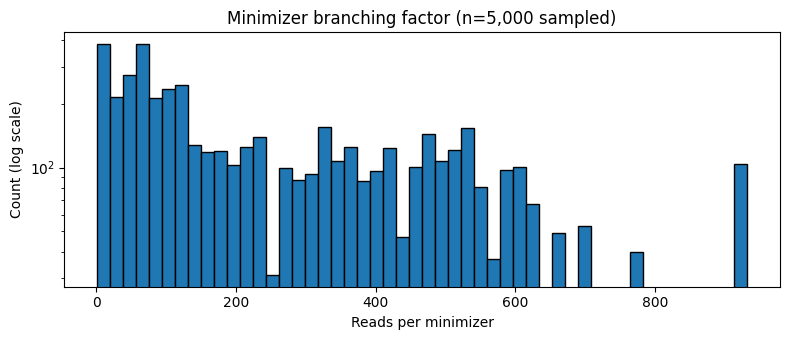

Reads/minimizer — median: 214,  p95: 631,  p99: 932,  max: 932
Suggested MAX_READS_PER_KMER: 631  (p95 value)


In [13]:
# Sample a small set of minimizers and inspect how many reads each maps to.
# High branching (many reads per minimizer) slows extension; the distribution
# informs a good max_reads_per_kmer setting.
import contextlib

BRANCH_SAMPLE = 5000

all_keys: list[bytes] = []
with contextlib.ExitStack() as stack:
    mi_txns_dbs = [(stack.enter_context(env.begin()), db) for env, db, _ in mi_shards]
    for mi_txn, mi_db in mi_txns_dbs:
        cursor = mi_txn.cursor(db=mi_db)
        cursor.first()
        while len(all_keys) < BRANCH_SAMPLE * 10 and cursor.key():
            all_keys.append(bytes(cursor.key()))
            cursor.next()

sample_keys = random.Random(SEED + 2).sample(all_keys, min(BRANCH_SAMPLE, len(all_keys)))

branch_counts = []
with contextlib.ExitStack() as stack:
    mi_txns_dbs = [(stack.enter_context(env.begin()), db) for env, db, _ in mi_shards]
    for key in sample_keys:
        total = 0
        for mi_txn, mi_db in mi_txns_dbs:
            c = mi_txn.cursor(db=mi_db)
            if c.set_key(key):
                total += sum(1 for _ in c.iternext_dup(keys=False))
        branch_counts.append(total)

branch_counts.sort()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(branch_counts, bins=50, edgecolor="black", log=True)
ax.set_xlabel("Reads per minimizer")
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Minimizer branching factor (n={len(branch_counts):,} sampled)")
plt.tight_layout()
plt.show()

p50 = branch_counts[len(branch_counts) // 2]
p95 = branch_counts[int(len(branch_counts) * 0.95)]
p99 = branch_counts[int(len(branch_counts) * 0.99)]
print(f"Reads/minimizer — median: {p50},  p95: {p95},  p99: {p99},  max: {max(branch_counts)}")
print(f"Suggested MAX_READS_PER_KMER: {p95}  (p95 value)")

## 3  Inspect reads

Sample a small number of reads and examine their minimizer count and bp-span distributions.
The span (last minimizer position − first minimizer position) is a lower bound on read length.

In [14]:
N_INSPECT = 2000

rng_inspect = random.Random(SEED + 1)
import contextlib
with contextlib.ExitStack() as stack:
    reads_txns_dbs = [(stack.enter_context(env.begin()), db) for env, db, _ in reads_shards]
    reads_txns_dbs_metas = [(txn, db, meta) for (txn, db), (_, _, meta) in zip(reads_txns_dbs, reads_shards)]

    inspect_ids = _sample_read_ids(reads_txns_dbs_metas, N_INSPECT, rng_inspect)
    n_mers_list: list[int] = []
    span_list: list[float] = []
    for rid in inspect_ids:
        val = _get_read_multi(reads_txns_dbs, reads_shard_ranges, rid)
        if val is None:
            continue
        mids, pos = _decode_read(val, has_positions)
        n_mers_list.append(len(mids))
        if has_positions and len(pos) >= 2:
            span_list.append(float(int(pos.max()) - int(pos.min())))

print(f"Sampled {len(n_mers_list)} reads")
print(f"Minimizers per read  — mean: {np.mean(n_mers_list):.1f}  median: {np.median(n_mers_list):.0f}  max: {np.max(n_mers_list)}")
if span_list:
    print(f"Minimizer span (bp)  — mean: {np.mean(span_list):.1f}  median: {np.median(span_list):.0f}  max: {np.max(span_list):.0f}")

Sampled 826 reads
Minimizers per read  — mean: 13.9  median: 14  max: 26
Minimizer span (bp)  — mean: 110.9  median: 114  max: 132


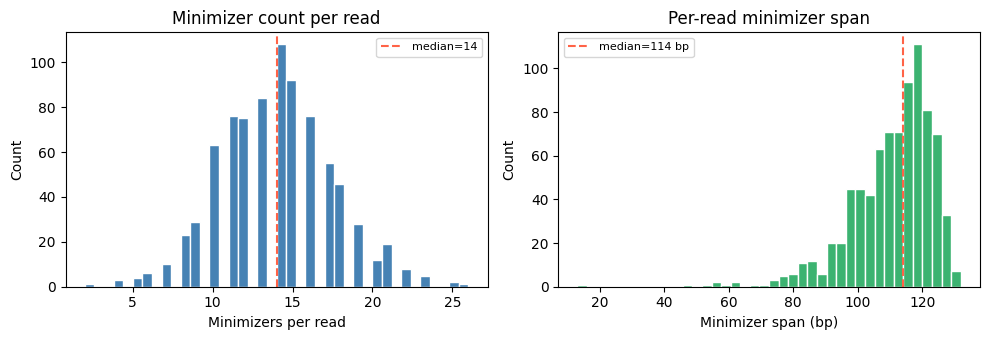

In [15]:
fig, axes = plt.subplots(1, 2 if span_list else 1, figsize=(10 if span_list else 5, 3.5))
axes = np.atleast_1d(axes)

axes[0].hist(n_mers_list, bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Minimizers per read")
axes[0].set_ylabel("Count")
axes[0].set_title("Minimizer count per read")
axes[0].axvline(np.median(n_mers_list), color="tomato", linestyle="--", label=f"median={np.median(n_mers_list):.0f}")
axes[0].legend(fontsize=8)

if span_list:
    axes[1].hist(span_list, bins=40, color="mediumseagreen", edgecolor="white")
    axes[1].set_xlabel("Minimizer span (bp)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Per-read minimizer span")
    axes[1].axvline(np.median(span_list), color="tomato", linestyle="--",
                    label=f"median={np.median(span_list):.0f} bp")
    axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 4  Sample paths

Sample up to `N_PATHS` assembly-free de Bruijn paths.  Each path is seeded from a
random read, then extended forward and backward by the greedy consensus rule: at each
step, the most-supported next minimizer (must be unambiguous and exceed `MIN_SUPPORT`) is
added to the path.

In [18]:
import contextlib

rng = random.Random(SEED)

read_cache = _LRUCache(maxsize=100_000)
minimizer_cache = _LRUCache(maxsize=50_000)
intersection_cache = _LRUCache(maxsize=10_000)

with contextlib.ExitStack() as stack:
    reads_txns_dbs = [(stack.enter_context(env.begin()), db) for env, db, _ in reads_shards]
    reads_txns_dbs_metas = [(txn, db, meta) for (txn, db), (_, _, meta) in zip(reads_txns_dbs, reads_shards)]
    mi_txns_dbs = [(stack.enter_context(env.begin()), db) for env, db, _ in mi_shards]

    seed_ids = _sample_read_ids(
        reads_txns_dbs_metas,
        n=min(N_PATHS * 200, 100_000),
        rng=rng,
    )
    print(f"Candidate seed reads: {len(seed_ids):,}; targeting {N_PATHS} paths")

    sampled_results: list[PathResult] = []
    attempts = 0

    with Progress(*_PROGRESS_COLUMNS) as progress:
        task = progress.add_task("Sampling paths", total=N_PATHS)
        for seed_id in seed_ids:
            if len(sampled_results) >= N_PATHS:
                break
            attempts += 1
            result = _sample_path(
                seed_read_id=seed_id,
                reads_txns_dbs=reads_txns_dbs,
                shard_ranges=reads_shard_ranges,
                has_positions=has_positions,
                mi_txns_dbs=mi_txns_dbs,
                bloom=bloom,
                k=K,
                max_path_mers=MAX_PATH_MERS,
                min_support=MIN_SUPPORT,
                max_reads_per_kmer=MAX_READS_PER_KMER,
                rng=rng,
                read_cache=read_cache,
                minimizer_cache=minimizer_cache,
                intersection_cache=intersection_cache,
            )
            if result is None or len(result.minimizer_ids) <= K:
                continue
            sampled_results.append(result)
            progress.advance(task)

print(f"Sampled {len(sampled_results)} paths in {attempts} attempts ({attempts - len(sampled_results)} failed)")
print(f"Read cache        : {len(read_cache):,} entries, {read_cache.hit_rate:.1%} hit rate")
print(f"Minimizer cache   : {len(minimizer_cache):,} entries, {minimizer_cache.hit_rate:.1%} hit rate")
print(f"Intersection cache: {len(intersection_cache):,} entries, {intersection_cache.hit_rate:.1%} hit rate")

Output()

Candidate seed reads: 40,000; targeting 200 paths


Sampled 200 paths in 566 attempts (366 failed)
Read cache        : 83,525 entries, 63.4% hit rate
Minimizer cache   : 14,200 entries, 82.2% hit rate
Intersection cache: 10,000 entries, 0.0% hit rate


In [19]:
path_lengths = [len(r.minimizer_ids) for r in sampled_results]
path_bp_spans = [sum(r.distances) for r in sampled_results if r.distances]
all_support = [s for r in sampled_results for s in r.support]
all_step_dists = [d for r in sampled_results for d in r.distances if d > 0]

print(f"Path minimizer count — min: {min(path_lengths)}  median: {np.median(path_lengths):.0f}  max: {max(path_lengths)}")
print(f"Path bp span         — min: {min(path_bp_spans):,}  median: {np.median(path_bp_spans):,.0f}  max: {max(path_bp_spans):,}")
print(f"Extension support    — mean: {np.mean(all_support):.2f}  median: {np.median(all_support):.0f}  max: {max(all_support)}")

Path minimizer count — min: 9  median: 46  max: 581
Path bp span         — min: 30  median: 413  max: 5,069
Extension support    — mean: 21.39  median: 16  max: 120


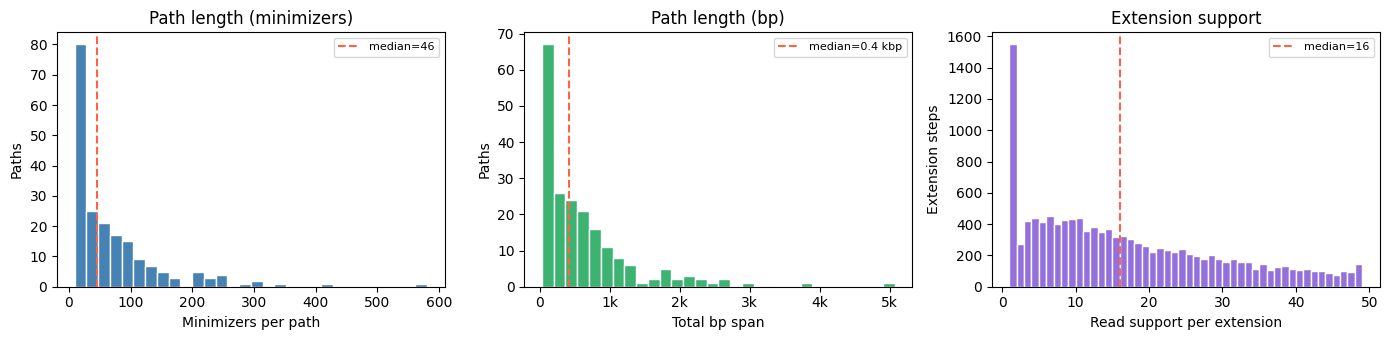

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Path length (minimizer count)
axes[0].hist(path_lengths, bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Minimizers per path")
axes[0].set_ylabel("Paths")
axes[0].set_title("Path length (minimizers)")
axes[0].axvline(np.median(path_lengths), color="tomato", linestyle="--",
                label=f"median={np.median(path_lengths):.0f}")
axes[0].legend(fontsize=8)

# Path bp span
axes[1].hist(path_bp_spans, bins=30, color="mediumseagreen", edgecolor="white")
axes[1].set_xlabel("Total bp span")
axes[1].set_ylabel("Paths")
axes[1].set_title("Path length (bp)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else str(int(x))))
axes[1].axvline(np.median(path_bp_spans), color="tomato", linestyle="--",
                label=f"median={np.median(path_bp_spans)/1000:.1f} kbp")
axes[1].legend(fontsize=8)

# Per-step extension support
bins_sup = range(min(all_support), min(max(all_support) + 2, 50))
axes[2].hist(all_support, bins=bins_sup, color="mediumpurple", edgecolor="white")
axes[2].set_xlabel("Read support per extension")
axes[2].set_ylabel("Extension steps")
axes[2].set_title("Extension support")
axes[2].axvline(np.median(all_support), color="tomato", linestyle="--",
                label=f"median={np.median(all_support):.0f}")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

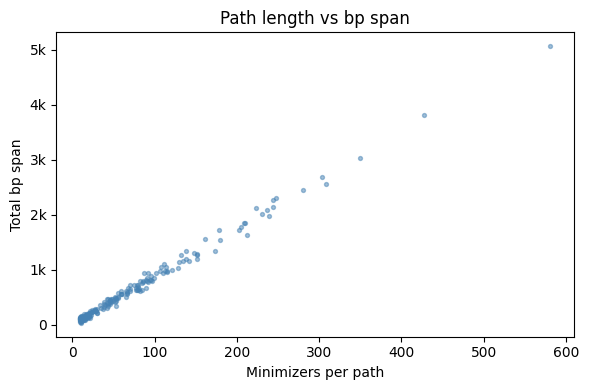

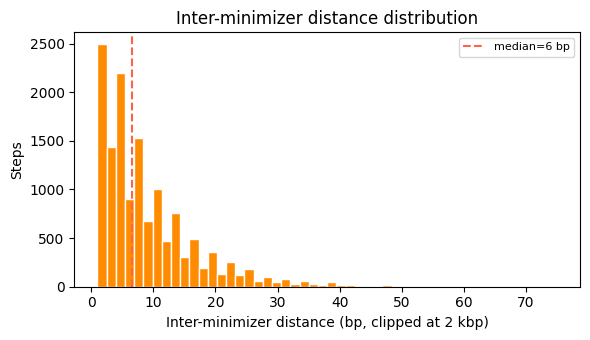

In [21]:
# Scatter: path bp span vs minimizer count — reveals paths that span many bp with few mers
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(path_lengths, path_bp_spans, s=8, alpha=0.5, color="steelblue")
ax.set_xlabel("Minimizers per path")
ax.set_ylabel("Total bp span")
ax.set_title("Path length vs bp span")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else str(int(x))))
fig.tight_layout()
plt.show()

# Inter-minimizer distance distribution
fig, ax = plt.subplots(figsize=(6, 3.5))
clipped = [d for d in all_step_dists if d <= 2000]
ax.hist(clipped, bins=50, color="darkorange", edgecolor="white")
ax.set_xlabel("Inter-minimizer distance (bp, clipped at 2 kbp)")
ax.set_ylabel("Steps")
ax.set_title("Inter-minimizer distance distribution")
ax.axvline(np.median(clipped), color="tomato", linestyle="--",
           label=f"median={np.median(clipped):.0f} bp")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5  Path combo sketches

For each path, compute a per-bin combination minimizer sketch.  A combination hash is the
canonical (commutative) hash of a pair of minimizer IDs separated by a bp distance falling
within a given bin.  Only hashes ≤ `COMBO_DENSITY × 2⁶⁴` are retained (density thinning,
must match `--combo-density` used in rust-mdbg).

In [22]:
use_paths = sampled_results[:INSERT_SIZE_PATHS]
print(f"Using {len(use_paths)} paths for insert size estimation")

path_bin_sketches = _build_path_bin_sketches(use_paths, INSERT_SIZE_BINS, COMBO_DENSITY)

# Summary of hash counts per path × bin
n_bins = len(INSERT_SIZE_BINS) - 1
hash_counts = np.array(
    [[len(path_bin_sketches[p][b]) for b in range(n_bins)] for p in range(len(use_paths))],
    dtype=np.float32,
)
print(f"Path-bin sketch shape: {hash_counts.shape}")
print(f"Mean hashes per bin (across paths): {np.mean(hash_counts, axis=0).round(1)}")
print(f"Paths with ≥ {MIN_PATH_HASHES_PER_BIN} hashes in any bin: "
      f"{(hash_counts >= MIN_PATH_HASHES_PER_BIN).any(axis=1).sum()}")

Using 50 paths for insert size estimation
Path-bin sketch shape: (50, 14)
Mean hashes per bin (across paths): [1150.4  799.7  554.4  405.6  323.   626.1  429.5  377.    73.6    0.
    0.     0.     0.     0. ]
Paths with ≥ 50 hashes in any bin: 43


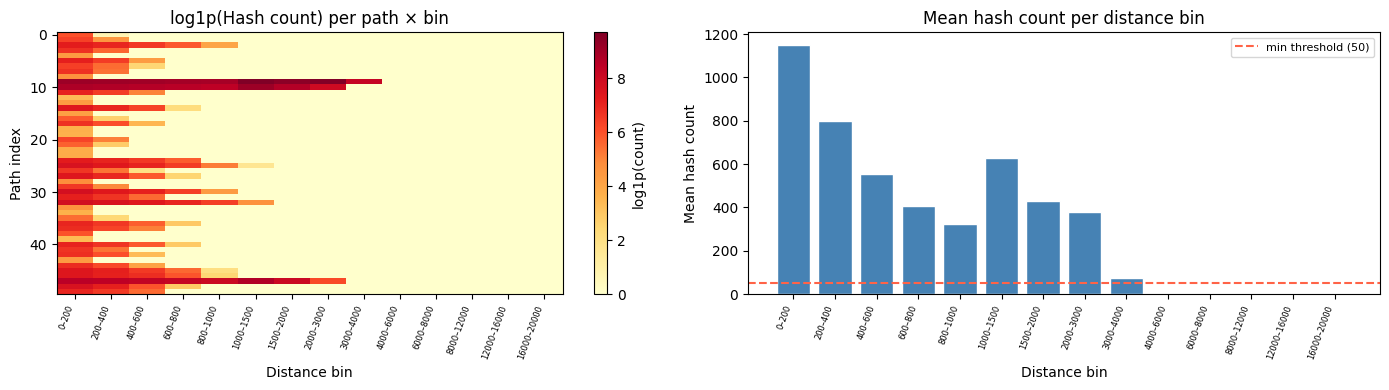

In [23]:
bin_labels = [f"{int(INSERT_SIZE_BINS[i])}–{int(INSERT_SIZE_BINS[i+1])}" for i in range(n_bins)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap: hash counts per path × bin
im0 = axes[0].imshow(
    np.log1p(hash_counts), aspect="auto", interpolation="nearest", cmap="YlOrRd",
)
axes[0].set_xlabel("Distance bin")
axes[0].set_ylabel("Path index")
axes[0].set_title("log1p(Hash count) per path × bin")
axes[0].set_xticks(range(n_bins))
axes[0].set_xticklabels(bin_labels, rotation=70, ha="right", fontsize=6)
plt.colorbar(im0, ax=axes[0], label="log1p(count)")

# Mean hash count per bin
mean_counts = np.mean(hash_counts, axis=0)
axes[1].bar(range(n_bins), mean_counts, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Distance bin")
axes[1].set_ylabel("Mean hash count")
axes[1].set_title("Mean hash count per distance bin")
axes[1].set_xticks(range(n_bins))
axes[1].set_xticklabels(bin_labels, rotation=70, ha="right", fontsize=6)
axes[1].axhline(MIN_PATH_HASHES_PER_BIN, color="tomato", linestyle="--",
                label=f"min threshold ({MIN_PATH_HASHES_PER_BIN})")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 6  Containment rates

For each (path, bin) pair query the PE combo LMDB to find what fraction of the path-bin
hashes also appear in the cross-pair (R1×R2) sketch.  A high containment rate in a given
bin indicates that many read pairs are separated by that distance, which reveals the insert
size distribution.

In [24]:
pe_shards = _open_pe_combo_lmdb(PREFIX)

c_obs, n_hashes, n_pe = _compute_per_path_containment_rates(pe_shards, path_bin_sketches)

print(f"PE sketch: {n_pe:,} unique combo hashes  ({len(pe_shards)} shard(s))")
print(f"c_obs shape: {c_obs.shape}")
print(f"Mean containment per bin:\n  {dict(zip(bin_labels, np.nanmean(c_obs, axis=0).round(4)))}")
print(f"\nPath-bins with ≥ {MIN_PATH_HASHES_PER_BIN} hashes (used in inference): "
      f"{(n_hashes >= MIN_PATH_HASHES_PER_BIN).sum()}")

PE sketch: 32,756,064 unique combo hashes  (2 shard(s))
c_obs shape: (50, 14)
Mean containment per bin:
  {'0–200': np.float32(0.0), '200–400': np.float32(0.0), '400–600': np.float32(0.0892), '600–800': np.float32(0.3107), '800–1000': np.float32(0.021), '1000–1500': np.float32(0.0), '1500–2000': np.float32(0.0), '2000–3000': np.float32(0.0), '3000–4000': np.float32(0.0), '4000–6000': np.float32(nan), '6000–8000': np.float32(nan), '8000–12000': np.float32(nan), '12000–16000': np.float32(nan), '16000–20000': np.float32(nan)}

Path-bins with ≥ 50 hashes (used in inference): 123


/var/folders/3q/xc5q54nj3z1240xs4rh977wh0000gp/T/ipykernel_29808/4110931604.py:7: RuntimeWarning: Mean of empty slice
  print(f"Mean containment per bin:\n  {dict(zip(bin_labels, np.nanmean(c_obs, axis=0).round(4)))}")


/var/folders/3q/xc5q54nj3z1240xs4rh977wh0000gp/T/ipykernel_29808/3143084490.py:19: RuntimeWarning: Mean of empty slice
  mean_c = np.nanmean(c_display, axis=0)
/Users/timrozday/miniforge3/envs/genome_blender_dev/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


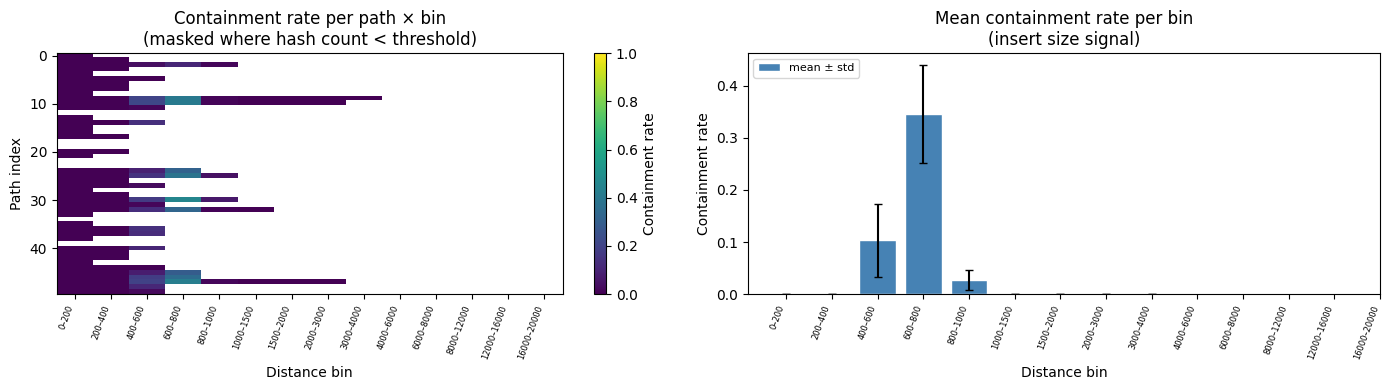

In [25]:
observed_mask = n_hashes >= MIN_PATH_HASHES_PER_BIN
c_display = np.where(observed_mask, c_obs, np.nan)  # mask low-hash bins

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap: containment rates
im = axes[0].imshow(
    c_display, aspect="auto", interpolation="nearest", cmap="viridis",
    vmin=0, vmax=1,
)
axes[0].set_xlabel("Distance bin")
axes[0].set_ylabel("Path index")
axes[0].set_title("Containment rate per path × bin\n(masked where hash count < threshold)")
axes[0].set_xticks(range(n_bins))
axes[0].set_xticklabels(bin_labels, rotation=70, ha="right", fontsize=6)
plt.colorbar(im, ax=axes[0], label="Containment rate")

# Mean containment per bin ± std (only observed bins)
mean_c = np.nanmean(c_display, axis=0)
std_c  = np.nanstd(c_display, axis=0)
bin_centres = [(INSERT_SIZE_BINS[i] + INSERT_SIZE_BINS[i + 1]) / 2 for i in range(n_bins)]
axes[1].bar(range(n_bins), mean_c, color="steelblue", edgecolor="white",
            yerr=std_c, capsize=3, label="mean ± std")
axes[1].set_xlabel("Distance bin")
axes[1].set_ylabel("Containment rate")
axes[1].set_title("Mean containment rate per bin\n(insert size signal)")
axes[1].set_xticks(range(n_bins))
axes[1].set_xticklabels(bin_labels, rotation=70, ha="right", fontsize=6)
axes[1].set_ylim(0, None)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 7  Fragment length inference

Fit a log-normal distribution to the per-path containment rates using the chosen
inference method (`INSERT_SIZE_INFERENCE`).  The model likelihood is:

```
p[b]        = LogNormal(log(mu_log), sigma_log).CDF(bin_hi[b])
            - LogNormal(log(mu_log), sigma_log).CDF(bin_lo[b])
expected[b] = p[b] * norm + rho
obs[p,b]    ~ Normal(expected[b], σ=0.05)  [masked by observed_mask]
```

In [26]:
if INSERT_SIZE_INFERENCE == "map":
    insert_result = estimate_fragment_length_map(
        pe_shards, path_bin_sketches, INSERT_SIZE_BINS,
        min_path_hashes_per_bin=MIN_PATH_HASHES_PER_BIN,
    )
    print(f"\nMAP result:")
    print(f"  median insert size : {insert_result.median:.0f} bp")
    print(f"  mean insert size   : {insert_result.mean:.0f} bp")
    print(f"  mu_log             : {insert_result.mu_log:.3f}")
    print(f"  sigma_log          : {insert_result.sigma_log:.3f}")
    print(f"  rho                : {insert_result.rho:.4f}")
    print(f"  norm               : {insert_result.norm:.4f}")
    print(f"  n_bins_used        : {insert_result.n_bins_used}")
    print(f"  signal_reliable    : {insert_result.signal_reliable}")
else:
    insert_result = estimate_fragment_length(
        pe_shards, path_bin_sketches, INSERT_SIZE_BINS,
        min_path_hashes_per_bin=MIN_PATH_HASHES_PER_BIN,
        inference=INSERT_SIZE_INFERENCE,
    )
    print(f"\n{INSERT_SIZE_INFERENCE.upper()} result:")
    print(f"  median insert size : {insert_result.median:.0f} bp")
    print(f"  mean insert size   : {insert_result.mean:.0f} bp")
    print(f"  mu_log             : {insert_result.mu_log:.3f}  95% CI: [{insert_result.mu_log_ci[0]:.3f}, {insert_result.mu_log_ci[1]:.3f}]")
    print(f"  sigma_log          : {insert_result.sigma_log:.3f}  95% CI: [{insert_result.sigma_log_ci[0]:.3f}, {insert_result.sigma_log_ci[1]:.3f}]")
    print(f"  rho                : {insert_result.rho:.4f}")
    print(f"  norm               : {insert_result.norm:.4f}")
    print(f"  n_bins_used        : {insert_result.n_bins_used}")
    print(f"  signal_reliable    : {insert_result.signal_reliable}")

/var/folders/3q/xc5q54nj3z1240xs4rh977wh0000gp/T/ipykernel_29808/869142515.py:45: RuntimeWarning: Mean of empty slice
  print(f"Mean containment per bin: {np.round(np.nanmean(c_obs, axis=0), 4)}")


PE sketch: 32,756,064 unique hashes
Mean containment per bin: [0.     0.     0.0892 0.3107 0.021  0.     0.     0.     0.        nan
    nan    nan    nan    nan]


Sample: 100%|██████████████████████████████████████████| 700/700 [00:11, 62.02it/s, step size=2.98e-01, acc. prob=0.932]                                       


NUTS result:
  median insert size : 653 bp
  mean insert size   : 656 bp
  mu_log             : 6.481  95% CI: [6.434, 6.521]
  sigma_log          : 0.105  95% CI: [0.050, 0.145]
  rho                : 0.0042
  norm               : 0.4581
  n_bins_used        : 9
  signal_reliable    : True


/var/folders/3q/xc5q54nj3z1240xs4rh977wh0000gp/T/ipykernel_29808/4203879696.py:15: RuntimeWarning: Mean of empty slice
  mean_c_obs = np.nanmean(c_display, axis=0)


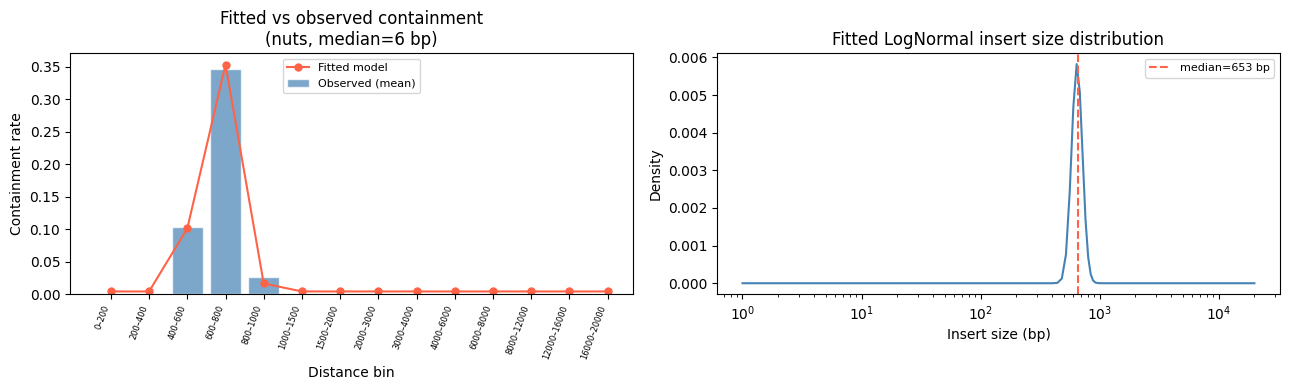

In [27]:
# Plot fitted LogNormal CDF differences vs observed mean containment per bin
mu_log_val   = insert_result.mu_log
sigma_log_val = insert_result.sigma_log
rho_val      = insert_result.rho
norm_val     = insert_result.norm

bin_lo_arr = np.array(INSERT_SIZE_BINS[:-1], dtype=np.float64)
bin_hi_arr = np.array(INSERT_SIZE_BINS[1:],  dtype=np.float64)

import scipy.stats
lognorm = scipy.stats.lognorm(s=sigma_log_val, scale=np.exp(mu_log_val))
p_fitted = lognorm.cdf(bin_hi_arr) - lognorm.cdf(bin_lo_arr)
expected_fitted = p_fitted * norm_val + rho_val

mean_c_obs = np.nanmean(c_display, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(n_bins), mean_c_obs, color="steelblue", edgecolor="white",
            alpha=0.7, label="Observed (mean)")
axes[0].plot(range(n_bins), expected_fitted, "o-", color="tomato",
             linewidth=1.5, markersize=5, label="Fitted model")
axes[0].set_xlabel("Distance bin")
axes[0].set_ylabel("Containment rate")
axes[0].set_title(f"Fitted vs observed containment\n({INSERT_SIZE_INFERENCE}, median={mu_log_val:.0f} bp)")
axes[0].set_xticks(range(n_bins))
axes[0].set_xticklabels(bin_labels, rotation=70, ha="right", fontsize=6)
axes[0].legend(fontsize=8)

# LogNormal PDF over a continuous range
x_bp = np.linspace(1, max(INSERT_SIZE_BINS), 500)
pdf_vals = lognorm.pdf(x_bp)
axes[1].plot(x_bp, pdf_vals, color="steelblue")
axes[1].axvline(math.exp(mu_log_val), color="tomato", linestyle="--",
                label=f"median={math.exp(mu_log_val):.0f} bp")
axes[1].set_xlabel("Insert size (bp)")
axes[1].set_ylabel("Density")
axes[1].set_title("Fitted LogNormal insert size distribution")
axes[1].legend(fontsize=8)
axes[1].set_xscale('log')

fig.tight_layout()
plt.show()

for env, db in pe_shards:
    env.close()

### NUTS posterior (if applicable)

When `INSERT_SIZE_INFERENCE = 'nuts'`, the cell below plots marginal posterior
distributions for each parameter and a pairs plot to reveal correlations.

Sample: 100%|██████████████████████████████████████████| 400/400 [00:04, 89.51it/s, step size=2.60e-01, acc. prob=0.672]                                       


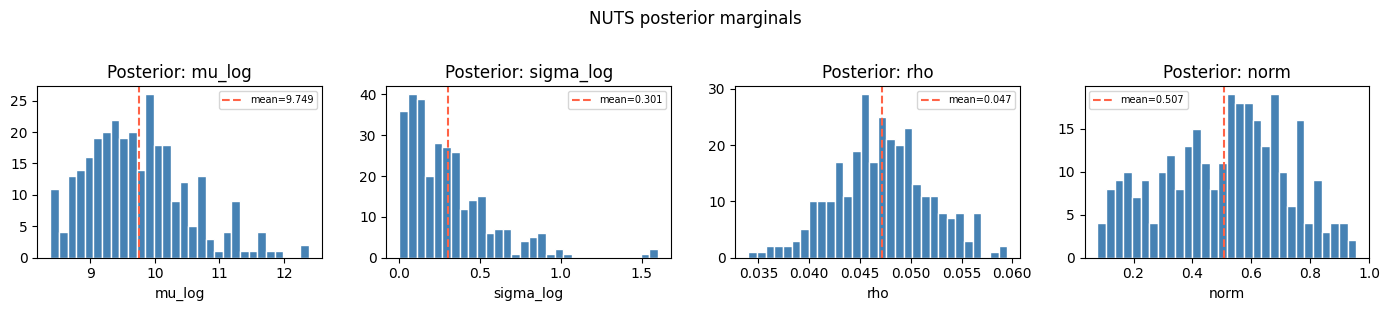

In [28]:
if INSERT_SIZE_INFERENCE == "nuts" and hasattr(insert_result, "mu_log_ci"):
    # Re-run NUTS to capture samples for plotting (or reuse mcmc object if in same scope)
    # Since estimate_fragment_length returns only summary statistics, re-run with
    # fewer samples for the visualisation.
    c_adjusted_np = np.clip(
        np.where(np.isnan(c_obs), 0.0, c_obs), 0.0, 1.0,
    ).astype(np.float32)
    observed_mask_np = (n_hashes >= MIN_PATH_HASHES_PER_BIN)

    c_adj_t  = torch.tensor(c_adjusted_np, dtype=torch.float32)
    bin_lo_t = torch.tensor(np.array(INSERT_SIZE_BINS[:-1], np.float32)).clamp(min=1.0)
    bin_hi_t = torch.tensor(np.array(INSERT_SIZE_BINS[1:],  np.float32)).clamp(min=1.0)
    n_path_t = torch.tensor(n_hashes, dtype=torch.float32)
    mask_t   = torch.tensor(observed_mask_np, dtype=torch.bool)
    model_args_plot = (c_adj_t, bin_lo_t, bin_hi_t, n_path_t, mask_t)

    pyro.clear_param_store()
    _nuts_kernel = NUTS(_fragment_length_pyro_model)
    _mcmc_plot = MCMC(_nuts_kernel, num_samples=300, warmup_steps=100, disable_progbar=False)
    _mcmc_plot.run(*model_args_plot)
    _samps = _mcmc_plot.get_samples()

    params_plot = ["mu_log", "sigma_log", "rho", "norm"]
    samp_arrays = {k: _samps[k].numpy() for k in params_plot}

    fig, axes = plt.subplots(1, len(params_plot), figsize=(14, 3))
    for ax, name in zip(axes, params_plot):
        ax.hist(samp_arrays[name], bins=30, color="steelblue", edgecolor="white")
        ax.set_xlabel(name)
        ax.set_title(f"Posterior: {name}")
        ax.axvline(np.mean(samp_arrays[name]), color="tomato", linestyle="--",
                   label=f"mean={np.mean(samp_arrays[name]):.3f}")
        ax.legend(fontsize=7)
    fig.suptitle("NUTS posterior marginals", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("Posterior samples not available for MAP/ADVI in this cell.")
    print(f"Estimate: median={insert_result.median:.0f} bp, sigma_log={insert_result.sigma_log:.3f}")

## 8  Read length estimation

Estimate the read length distribution via MAP fitting of a log-normal to minimizer spans
(bp distance between each read's first and last minimizer — a slight underestimate of the
true read length).

In [29]:
rng_rl = random.Random(SEED + 99)
rl_result = estimate_read_length_map(
    reads_shards, has_positions,
    n_reads=READ_LENGTH_READS,
    rng=rng_rl,
)
print(f"\nRead length MAP:")
print(f"  median span : {rl_result.median:.1f} bp")
print(f"  mean span   : {rl_result.mean:.1f} bp")
print(f"  mu_log      : {rl_result.mu_log:.3f}")
print(f"  sigma_log   : {rl_result.sigma_log:.3f}")
print(f"  n_reads     : {rl_result.n_reads}")
print(f"  signal_reliable: {rl_result.signal_reliable}")

Read length estimation: 999 reads with usable minimizer spans


NameError: name 'PyroAdam' is not defined

In [ ]:
import contextlib
import scipy.stats as _scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Re-collect spans for plotting (same rng seed)
rng_plot = random.Random(SEED + 99)
all_key_shard_plot: list[tuple[bytes, int]] = []
for shard_idx, (env, db, _) in enumerate(reads_shards):
    with env.begin() as txn:
        cursor = txn.cursor(db=db)
        for key, _ in cursor.iternext():
            all_key_shard_plot.append((key, shard_idx))

sample_pairs_plot = rng_plot.sample(all_key_shard_plot, min(READ_LENGTH_READS, len(all_key_shard_plot)))
plot_spans: list[float] = []
for key, shard_idx in sample_pairs_plot:
    env, db, _ = reads_shards[shard_idx]
    with env.begin() as txn:
        val = txn.get(key, db=db)
    if val is None:
        continue
    _, pos = _decode_read(val, has_positions=True)
    if len(pos) >= 5:
        s = float(int(pos.max()) - int(pos.min()))
        if s > 0:
            plot_spans.append(s)

# Histogram with fitted LogNormal overlay
axes[0].hist(plot_spans, bins=40, color="mediumseagreen", edgecolor="white",
             density=True, alpha=0.7, label="Observed spans")
if rl_result.signal_reliable:
    x_rl = np.linspace(1, np.percentile(plot_spans, 99.5), 400)
    fitted_ln = _scipy_stats.lognorm(s=rl_result.sigma_log, scale=rl_result.median)
    axes[0].plot(x_rl, fitted_ln.pdf(x_rl), color="tomato", linewidth=2,
                 label=f"Fitted LogNormal (median={rl_result.median:.0f} bp)")
axes[0].set_xlabel("Minimizer span (bp)")
axes[0].set_ylabel("Density")
axes[0].set_title("Read minimizer span distribution")
axes[0].legend(fontsize=8)

# CDF
axes[1].hist(plot_spans, bins=80, color="steelblue", edgecolor="none",
             density=True, cumulative=True, alpha=0.7, label="Empirical CDF")
if rl_result.signal_reliable:
    axes[1].plot(x_rl, fitted_ln.cdf(x_rl), color="tomato", linewidth=2, label="Fitted CDF")
axes[1].set_xlabel("Minimizer span (bp)")
axes[1].set_ylabel("Cumulative density")
axes[1].set_title("Read span CDF")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 9  Summary

Collect all estimated parameters in one place.

In [ ]:
summary = {
    "n_paths_sampled": len(sampled_results),
    "path_length_median_mers": float(np.median(path_lengths)),
    "path_span_median_bp": float(np.median(path_bp_spans)),
    "insert_size": {
        "inference": INSERT_SIZE_INFERENCE,
        "median_bp": insert_result.median,
        "mean_bp": insert_result.mean,
        "mu_log": insert_result.mu_log,
        "sigma_log": insert_result.sigma_log,
        "n_bins_used": insert_result.n_bins_used,
        "signal_reliable": insert_result.signal_reliable,
    },
    "read_length": {
        "median_bp": rl_result.median,
        "mean_bp": rl_result.mean,
        "mu_log": rl_result.mu_log,
        "sigma_log": rl_result.sigma_log,
        "n_reads": rl_result.n_reads,
        "signal_reliable": rl_result.signal_reliable,
    },
}

print(json.dumps(summary, indent=2))